In [1]:
import sys
sys.path.append("../src")

In [2]:
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import readers as readers

DATA_DIR = "../assets/data"
dfs: dict[str, pd.DataFrame] = readers.load_csv(DATA_DIR)

# Schema

![img](../assets/schemas/er-trans.png)

# 

# Merges

In [3]:
order_w_geo = dfs["orders"].rename(columns=lambda i: f"orders.{i}").merge(
    dfs["geography"].rename(columns=lambda i: f"geography.{i}"),
    "left",
    left_on="orders.zip",
    right_on="geography.zip"
)
items_w_prods = dfs["order_items"].rename(columns=lambda i: f"order_items.{i}").merge(
    dfs["products"].rename(columns=lambda i: f"products.{i}"),
    "left",
    left_on="order_items.product_id",
    right_on="products.product_id"
)
customer_w_geo = dfs["customers"].rename(columns=lambda i: f"customers.{i}").merge(
    dfs["geography"].rename(columns=lambda i: f"cus_geo.{i}"),
    "left",
    left_on="customers.zip",
    right_on="cus_geo.zip"
)

In [4]:
full_orders = order_w_geo.merge(
    customer_w_geo, "left",
    left_on="orders.customer_id",
    right_on="customers.customer_id"
)

full_order_items = items_w_prods.merge(
    full_orders, "left",
    left_on="order_items.order_id",
    right_on="orders.order_id"
)

full_returns = dfs["returns"].rename(columns=lambda i: f"returns.{i}").merge(
    full_order_items, "left",
    left_on="returns.order_id",
    right_on="orders.order_id"
)

full_reviews = dfs["reviews"].rename(columns=lambda i: f"reviews.{i}").merge(
    full_order_items, "left",
    left_on="reviews.order_id",
    right_on="orders.order_id"
)

In [ ]:
full_shipments = dfs["shipments"].rename(lambda i: f"shipments.{i}").merge(
    full_order_items
)

# Viz

## Products - Orders

In [ ]:
not_returned = ~full_order_items["orders.order_id"].isin(full_returns["orders.order_id"])

non_returned_df = full_order_items[not_returned]
non_returned_df["total"] = non_returned_df["order_items.unit_price"] * non_returned_df["order_items.quantity"]

In [28]:
def compare_profit_sold(
    group_by,
    top_k=10,
    *,
    xlabel=None,
    rot=None,
):
    if top_k is None or top_k > len(group_by):
        top_k = len(group_by)

    fig = plt.figure(figsize=(15, 5))
    axes = fig.subplots(1, 2)

    sort_revenue = group_by.sort_values(["total_revenue", "total_sold"], ascending=False).iloc[:top_k]
    sort_revenue.plot.bar(y="total_sold", ax=axes[0], ylabel="Items sold")
    sort_revenue.plot.line(
        y="total_revenue",
        secondary_y=True,
        rot=rot,
        color="orange",
        linestyle="none",
        marker="o",
        xlabel=xlabel,
        title=f"Top {top_k} most profitable products",
        ax=axes[0]
    )

    sort_sold = group_by.sort_values(["total_sold", "total_revenue"], ascending=False).iloc[:top_k]
    sort_sold.plot.bar(y="total_sold", ax=axes[1])
    sort_sold.plot.line(
        y="total_revenue",
        secondary_y=True,
        rot=rot,
        color="orange",
        linestyle="none",
        marker="o",
        xlabel=xlabel,
        ylabel="VND",
        title=f"Top {top_k} most sold products",
        ax=axes[1],
    )
    return fig

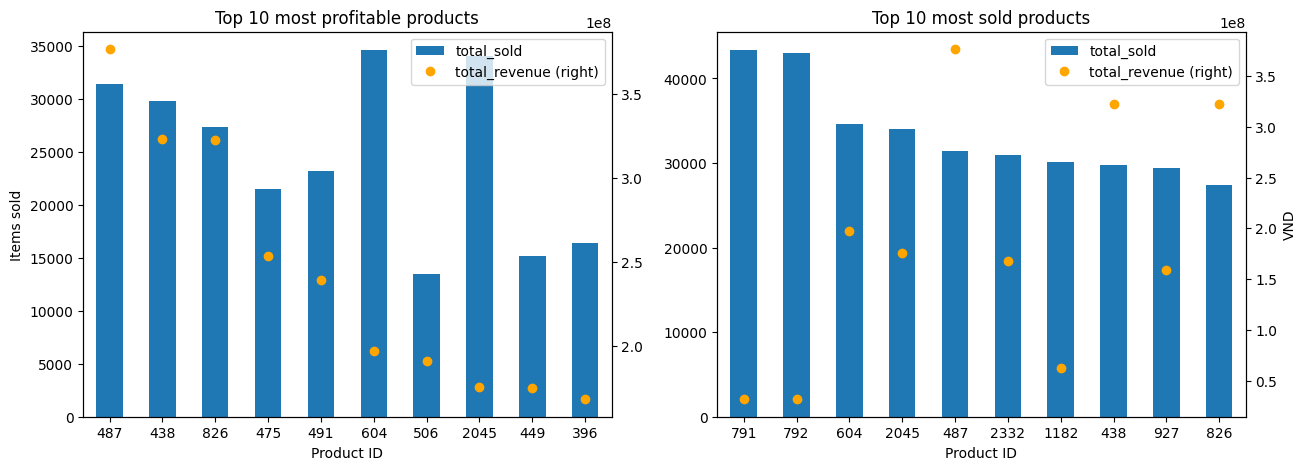

In [ ]:
gp_product = non_returned_df.groupby(["products.product_id", "products.product_name"]).agg(
    total_sold=("order_items.quantity", "sum"),
    total_revenue=("total", "sum")
).reset_index(1)
gp_product.index = gp_product.index.map(str)
compare_profit_sold(gp_product, xlabel="Product ID");

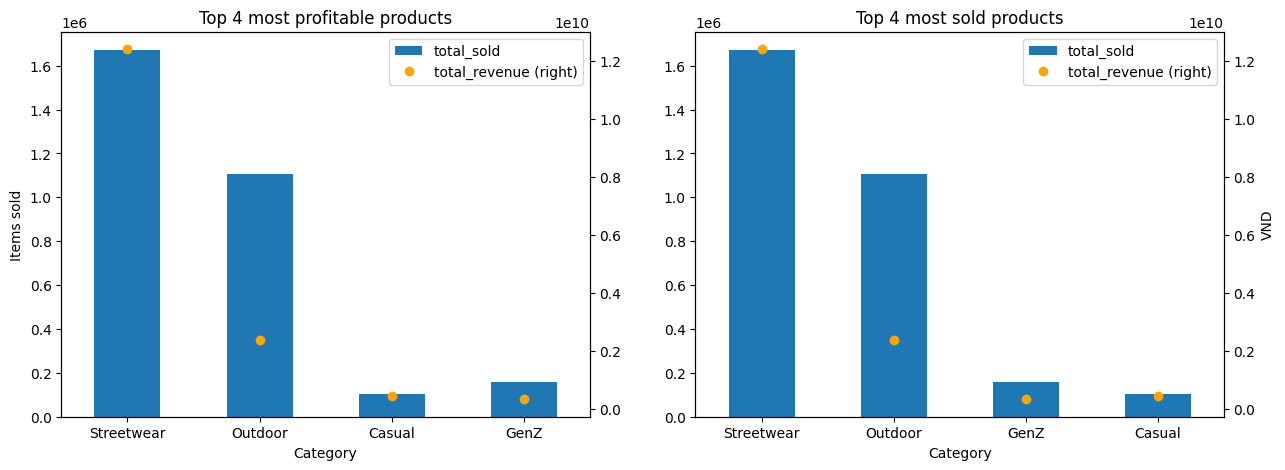

In [30]:
gp_cat = non_returned_df.groupby("products.category").agg(
    total_sold=("order_items.quantity", "sum"),
    total_revenue=("total", "sum")
)
compare_profit_sold(gp_cat, xlabel="Category");

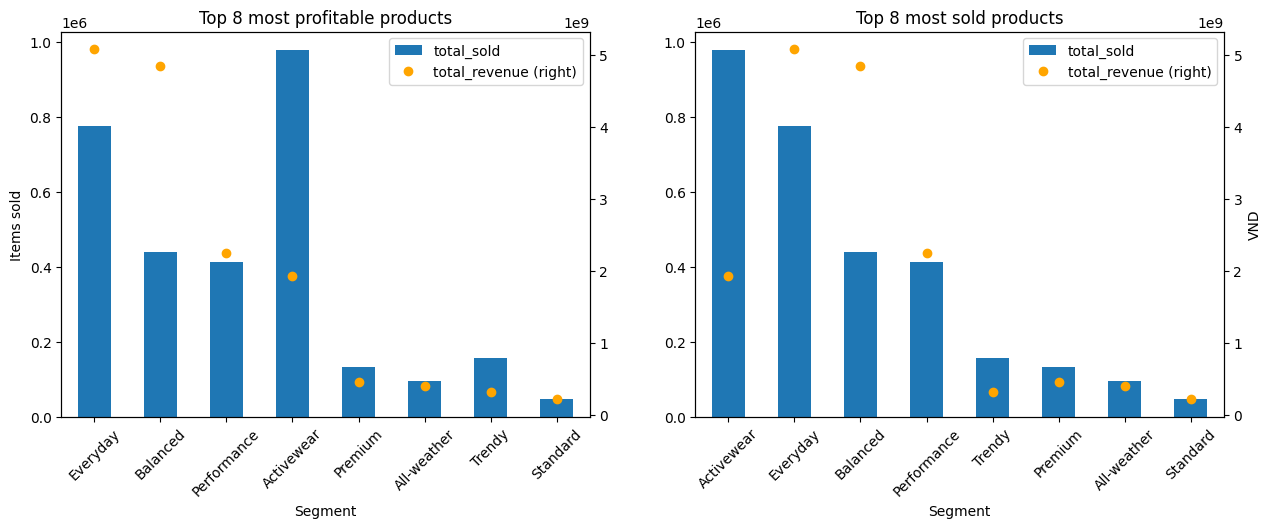

In [31]:
gp_seg = non_returned_df.groupby("products.segment").agg(
    total_sold=("order_items.quantity", "sum"),
    total_revenue=("total", "sum")
)
compare_profit_sold(gp_seg, xlabel="Segment", rot=45);

## Promotions

In [ ]:
promtions = dfs["promotions"]
promtions["start_month"] = promtions["start_date"].dt.month
promtions["end_month"] = promtions["end_date"].dt.month
promtions["start_day"] = promtions["start_date"].dt.day
promtions["end_day"] = promtions["end_date"].dt.day

In [ ]:
promtions.groupby(["promo_id"]).agg(
    start_day=("start_day", "unique"),
    end_day=("end_day", "unique"),
    start_month=("start_month", "unique"),
    end_month=("end_month", "unique"),
    name=("promo_name", 'unique')
)

## Products - Reviews

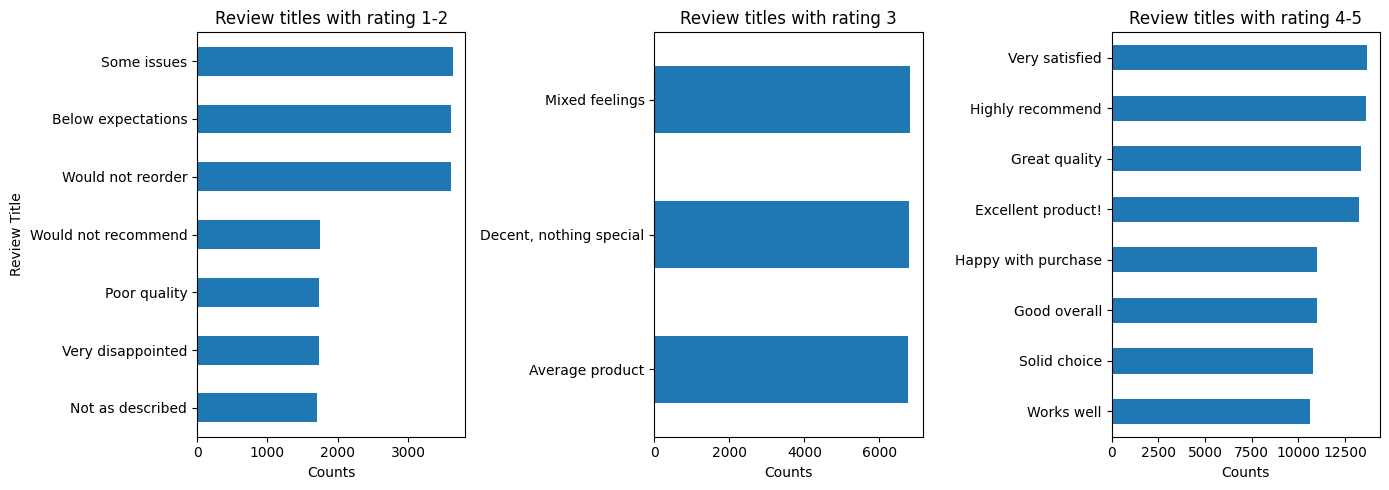

In [54]:
fig = plt.figure(figsize=(14, 5))
axes = fig.subplots(1, 3)

full_reviews["rating_bin"] = full_reviews["reviews.rating"].apply(lambda i: 0 if 1 <= i <= 2 else 1 if i == 3 else 2)
rating_groups = ["1-2", "3", "4-5"]
for rating_bin, rows in full_reviews.groupby("rating_bin"):
    rows.value_counts("reviews.review_title", ascending=True).plot.barh(
        xlabel="Counts",
        ylabel="",
        title=f"Review titles with rating {rating_groups[rating_bin]}",
        ax=axes[rating_bin]
    )

axes[0].set_ylabel("Review Title")
fig.tight_layout();

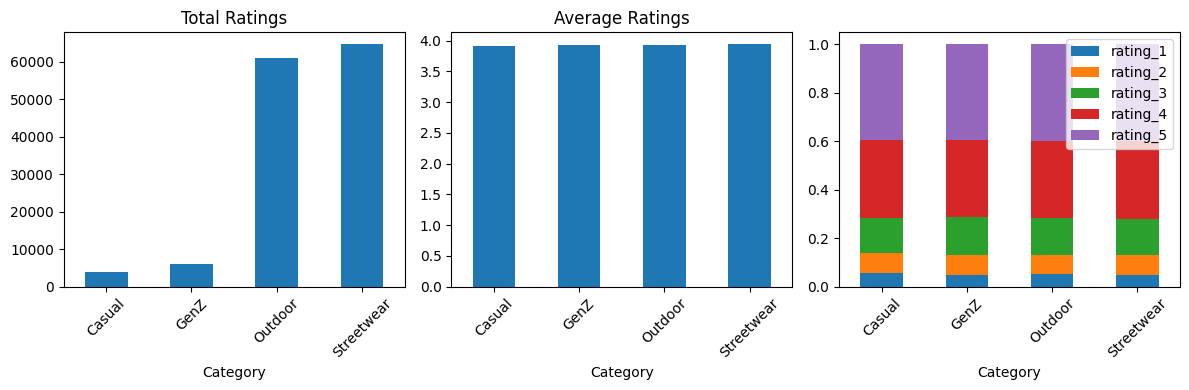

In [99]:
gp_category = full_reviews.groupby("products.category").agg(
    num_ratings=("reviews.review_id", "count"),
    avg_ratings=("reviews.rating", "mean"),
    rating_1=("reviews.rating", lambda row: (row == 1).sum() / len(row)),
    rating_2=("reviews.rating", lambda row: (row == 2).sum() / len(row)),
    rating_3=("reviews.rating", lambda row: (row == 3).sum() / len(row)),
    rating_4=("reviews.rating", lambda row: (row == 4).sum() / len(row)),
    rating_5=("reviews.rating", lambda row: (row == 5).sum() / len(row)),
)

fig = plt.figure(figsize=(12, 4))
axes = fig.subplots(1, 3)

gp_category.plot.bar(
    y="num_ratings",
    xlabel="Category",
    rot=45,
    ax=axes[0],
    title="Total Ratings",
    stacked=True,
    legend=False,
)
gp_category.plot.bar(
    y="avg_ratings",
    xlabel="Category",
    rot=45,
    ax=axes[1],
    title="Average Ratings",
    stacked=True,
    legend=False,
)
gp_category.plot.bar(
    y=[f"rating_{i}" for i in range(1, 6)],
    xlabel="Category",
    stacked=True,
    rot=45,
    ax=axes[2]
)
fig.tight_layout();

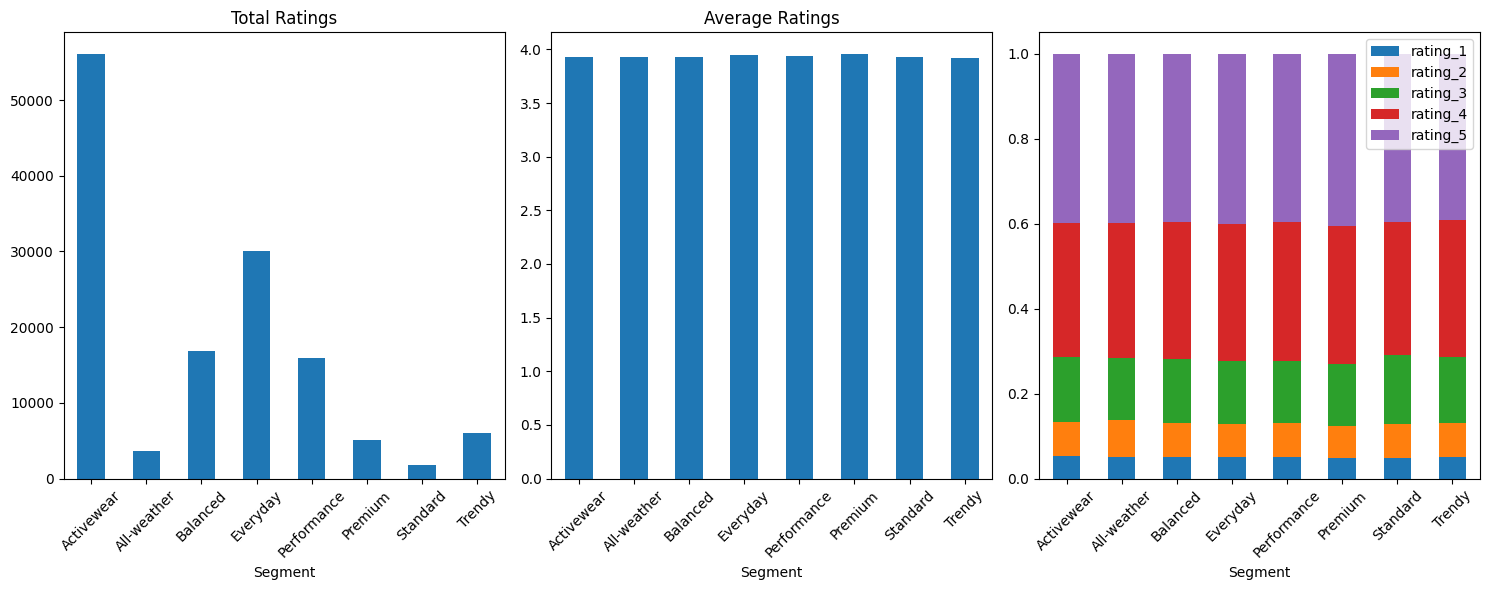

In [98]:
gp_category = full_reviews.groupby("products.segment").agg(
    num_ratings=("reviews.review_id", "count"),
    avg_ratings=("reviews.rating", "mean"),
    rating_1=("reviews.rating", lambda row: (row == 1).sum() / len(row)),
    rating_2=("reviews.rating", lambda row: (row == 2).sum() / len(row)),
    rating_3=("reviews.rating", lambda row: (row == 3).sum() / len(row)),
    rating_4=("reviews.rating", lambda row: (row == 4).sum() / len(row)),
    rating_5=("reviews.rating", lambda row: (row == 5).sum() / len(row)),
)

fig = plt.figure(figsize=(15, 6))
axes = fig.subplots(1, 3)

gp_category.plot.bar(
    y="num_ratings",
    xlabel="Segment",
    rot=45,
    ax=axes[0],
    title="Total Ratings",
    stacked=True,
    legend=False,
)
gp_category.plot.bar(
    y="avg_ratings",
    xlabel="Segment",
    rot=45,
    ax=axes[1],
    title="Average Ratings",
    stacked=True,
    legend=False,
)
gp_category.plot.bar(
    y=[f"rating_{i}" for i in range(1, 6)],
    xlabel="Segment",
    stacked=True,
    rot=45,
    ax=axes[2]
)
fig.tight_layout();

## Customer

In [ ]:
customer_gp = non_returned_df.groupby("customers.customer_id").agg(
    num_orders=("orders.order_id", "nunique"),
    unique_products=("products.product_id", "nunique"),
    num_items=("order_items.quantity", "sum"),
)
return_gp = full_returns.groupby("customers.customer_id").agg(
    num_returns=("orders.order_id", "nunique"),
    unique_return_products=("products.product_id", "nunique"),
    num_return_items=("returns.return_quantity", "sum"),
    most_returned=("products.product_id", pd.Series.mode)
)

customer_gp = customer_gp.merge(return_gp, "left", left_index=True, right_index=True)

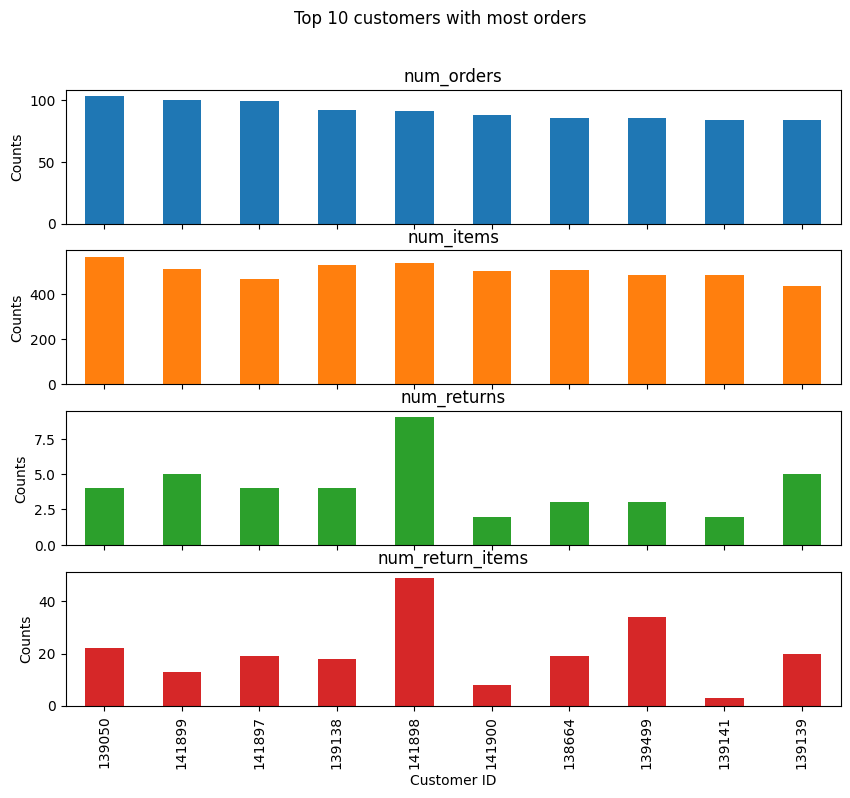

In [ ]:
top_k = 10

customer_gp.sort_values(["num_orders", "num_items", "num_returns"], inplace=True, ascending=False)
customer_gp.iloc[:top_k].plot.bar(
    y=["num_orders", "num_items", "num_returns", "num_return_items"],
    ylabel="Counts",
    xlabel="Customer ID",
    title="Top 10 customers with most orders",
    subplots=True,
    legend=False,
    figsize=(10, 8),
);

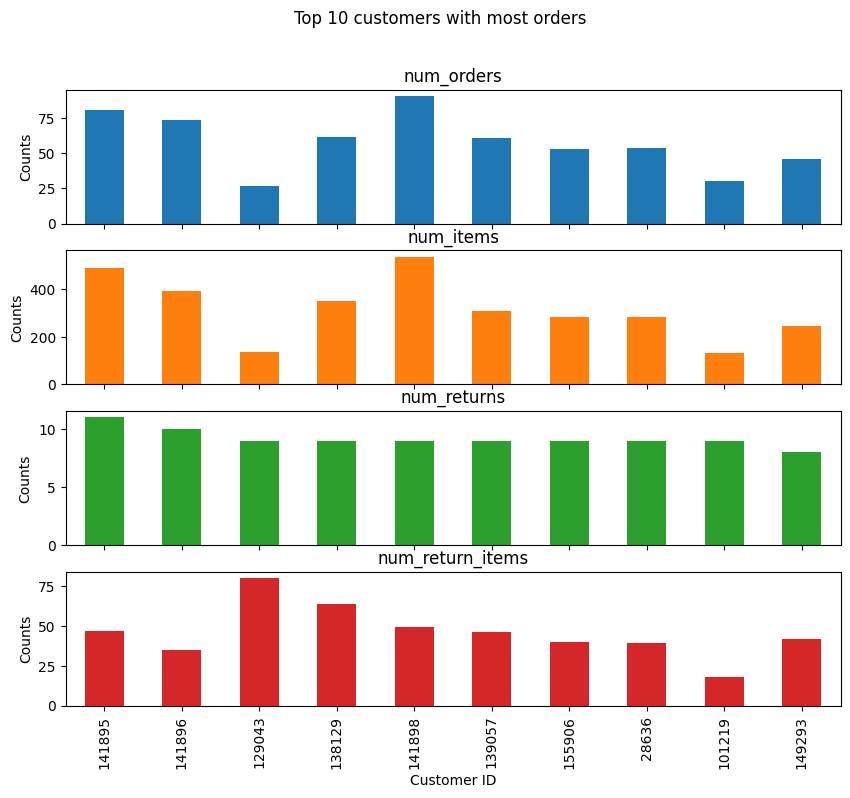

In [111]:
top_k = 10

customer_gp.sort_values(["num_returns", "num_return_items", "num_orders"], inplace=True, ascending=False)
customer_gp.iloc[:top_k].plot.bar(
    y=["num_orders", "num_items", "num_returns", "num_return_items"],
    ylabel="Counts",
    xlabel="Customer ID",
    title="Top 10 customers with most orders",
    subplots=True,
    legend=False,
    figsize=(10, 8),
);